In [1]:
# This file is copied from quantum-optimization-algorithms (https://github.com/SMU-Quantum/quantum-optimization-algorithms)
# Copyright (c) 2025 Monit Sharma
# Licensed under the MIT License
import numpy as np
from math import comb
from typing import List
import networkx as nx

from itertools import combinations
from qiskit.circuit import QuantumCircuit, Parameter

def generate_pauli_strings(num_qubits: int, num_features: int, num_operators: int) -> List[str]:
        """
        Generate Pauli strings for n qubits with m strings and k-body Pauli correlation.

        Args:
        - n: The number of qubits
        - m: The number of Pauli strings to generate
        - k: The number of Pauli operators in each string

        Returns:
        - pauli_strings: A list of Pauli strings
        """
        # Ensure k is not greater than n
        n = num_qubits
        m = num_features
        k = num_operators

        if k > n:
            raise ValueError("k cannot be greater than n")
        
        # Calculate the maximum number of Pauli strings that can be generated
        max_pauli_strings = 3 * comb(n, k)
        
        # Check if the requested number of strings exceeds the maximum possible
        if m > max_pauli_strings:
            raise ValueError(f"The maximum number of Pauli strings that can be generated for n={n} and k={k} is {max_pauli_strings}. The requested m={m} exceeds this limit.")
        
        # Define Pauli operators
        pauli_ops = ['X', 'Y']
        
        # Generate all possible positions for k Pauli operators in n qubits
        positions = list(combinations(range(n), k))

        # Initialize the list to hold the final Pauli strings
        pauli_strings = []

        # Generate the Pauli strings for each Pauli operator
        for op in pauli_ops:
            for pos in positions:
                pauli_string = ['I'] * n  # Start with all 'I'$
                for i in pos:
                    pauli_string[i] = op  # Place the Pauli operator at the specified positions
                pauli_strings.append(''.join(pauli_string))  # Convert list to string and add to the result list
        
        # Ensure the output list length matches m
        return pauli_strings[:m]


In [7]:
n_qubits=4
n_features = 10

strings = generate_pauli_strings(num_qubits=4, num_features=10, num_operators=2)
coeffs = 2 * (np.random.rand(10) - 0.5)
print(strings)
print(coeffs)


['XXII', 'XIXI', 'XIIX', 'IXXI', 'IXIX', 'IIXX', 'YYII', 'YIYI', 'YIIY', 'IYYI']
[ 0.51047076  0.44370394  0.80896688 -0.20323024 -0.49361216  0.22069585
  0.04383633 -0.46574492 -0.7893976   0.75244702]


In [20]:
from qiskit import QuantumCircuit
from typing import List
import pandas as pd

class encoding_stratetgy():
    def generate_pubs(self, data : pd.DataFrame) -> list[tuple[QuantumCircuit, List[float]]]:
        pass

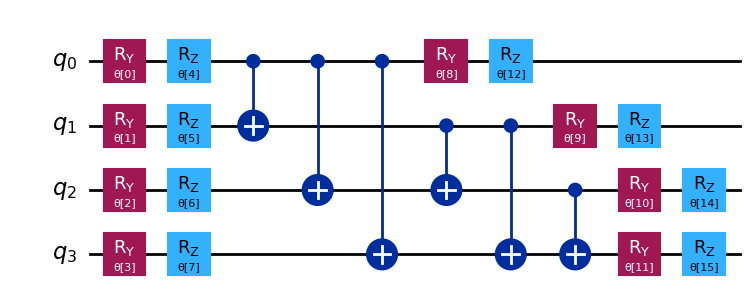

In [7]:
test = efficient_su2(num_qubits=4, 
              reps=1, 
              insert_barriers=False, 
              su2_gates=['ry', 'rz'], 
              entanglement='full', 
              parameter_prefix='θ')

test.draw("mpl")

In [21]:
from qiskit.circuit.library import efficient_su2
from sklearn.preprocessing import MinMaxScaler

class unitary_encoding_strategy(encoding_stratetgy):
    def __init__(self, 
                 n_qubits: int = None,
                 reps: int = 1,
                 su2_gates: List[str] = ['ry', 'rx'],
                 entanglement: str = 'full'):
                
        self.n_features = n_features
        self.n_qubits = n_qubits
        self.reps = reps
        self.su_2_gates = su2_gates
        self.entanglement = entanglement


    def generate_pubs(self, data : pd.DataFrame) -> List[tuple[QuantumCircuit, List[float]]]:
        circuit = efficient_su2(self.n_qubits, 
                                reps=self.reps,
                                su2_gates=self.su_2_gates,
                                entanglement=self.entanglement,)
        
        scaled_data = MinMaxScaler().fit_transform(data.values)
        scaled_data = 2*np.pi*scaled_data    

        pubs = []

        n_params = circuit.num_parameters
        if scaled_data.shape[1] < n_params:
            scaled_data = np.hstack([scaled_data, np.zeros((scaled_data.shape[0], n_params - scaled_data.shape[1]))])


        for row in scaled_data:
            pubs.append((circuit, row))

        return pubs


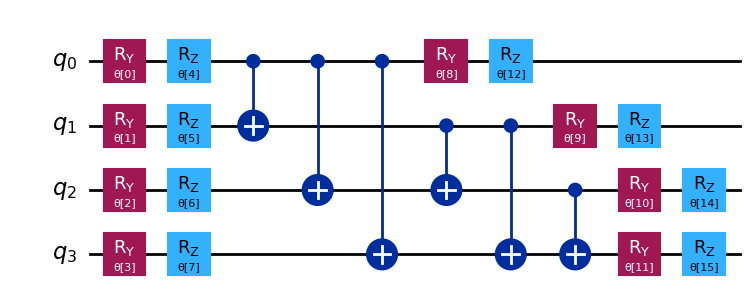

In [51]:
import numpy as np

test_n_features = 12
test_n_qubits = 4
test_data = pd.DataFrame(np.random.rand(100, test_n_features), columns=[f"feature_{i}" for i in range(test_n_features)])

es = unitary_encoding_strategy(n_qubits=test_n_qubits,
                              reps=1,
                              su2_gates=['ry', 'rz'],
                              entanglement='full')

test_pubs = es.generate_pubs(test_data)

test_circuit, test_parameters = test_pubs[0]

test_circuit.draw("mpl")

In [22]:
def engineer_features(data: pd.DataFrame,
                      encoding_stratetgy,
                      result_getter) -> pd.DataFrame:
    pubs = encoding_stratetgy.generate_pubs(data)
    results = result_getter.get_results(pubs)
    return results

In [23]:
class result_getter():
    def get_results(self, pubs):
        return np.random.rand(len(pubs), 10)

In [67]:
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Estimator

# This file is copied from quantum-optimization-algorithms (https://github.com/SMU-Quantum/quantum-optimization-algorithms)
# Copyright (c) 2025 Monit Sharma
# Licensed under the MIT License
import numpy as np
from math import comb
from typing import List
import networkx as nx

from itertools import combinations
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.quantum_info import SparsePauliOp

def generate_pauli_strings(num_qubits: int, num_features: int, num_operators: int) -> List[str]:
        """
        Generate Pauli strings for n qubits with m strings and k-body Pauli correlation.

        Args:
        - n: The number of qubits
        - m: The number of Pauli strings to generate
        - k: The number of Pauli operators in each string

        Returns:
        - pauli_strings: A list of Pauli strings
        """
        # Ensure k is not greater than n
        n = num_qubits
        m = num_features
        k = num_operators

        if k > n:
            raise ValueError("k cannot be greater than n")
        
        # Calculate the maximum number of Pauli strings that can be generated
        max_pauli_strings = 3 * comb(n, k)
        
        # Check if the requested number of strings exceeds the maximum possible
        if m > max_pauli_strings:
            raise ValueError(f"The maximum number of Pauli strings that can be generated for n={n} and k={k} is {max_pauli_strings}. The requested m={m} exceeds this limit.")
        
        # Define Pauli operators
        pauli_ops = ['X', 'Y', 'Z']
        
        # Generate all possible positions for k Pauli operators in n qubits
        positions = list(combinations(range(n), k))

        # Initialize the list to hold the final Pauli strings
        pauli_strings = []

        # Generate the Pauli strings for each Pauli operator
        for op in pauli_ops:
            for pos in positions:
                pauli_string = ['I'] * n  # Start with all 'I'$
                for i in pos:
                    pauli_string[i] = op  # Place the Pauli operator at the specified positions
                pauli_strings.append(''.join(pauli_string))  # Convert list to string and add to the result list
        
        # Ensure the output list length matches m
        return pauli_strings[:m]


class pce_result_getter(result_getter):
    
    def __init__(self, 
                 num_qubits, 
                 num_features, 
                 num_operators, 
                 estimator : Estimator):
        
        self.estimator = estimator
        self.pce_strings = generate_pauli_strings(num_qubits, num_features, num_operators)
        self.ops = SparsePauliOp(self.pce_strings)

    def get_results(self, pubs):
        
        estimator_pubs = []

        for circ, params in pubs:
            for op in self.ops:
                estimator_pubs.append((circ, op, params))

        circuit_results = self.estimator.run(pubs=estimator_pubs).result()

        results = pd.DataFrame(columns=self.pce_strings)
        index = 0
        for row in range(len(pubs)):

            for column in self.pce_strings:

                results.loc[row, column] = float(circuit_results[index].data.evs)
                index += 1

        return results

In [71]:
sim = AerSimulator()
test_estimator = Estimator(mode=sim)

test_result_getter = pce_result_getter(num_qubits=test_n_qubits, 
                                       num_features=12, 
                                       num_operators=2, 
                                       estimator=test_estimator)

test_results = test_result_getter.get_results(test_pubs)
print(test_results)

        XXII      XIXI      XIIX  ...      IYYI      IYIY      IIYY
0  -0.277344  0.062988  -0.14502  ...  0.057617  0.225586 -0.379395
1   0.289062 -0.020996  0.047852  ... -0.010742 -0.004395  0.027344
2   0.288574 -0.149902 -0.083496  ...  0.371582  0.008301 -0.141113
3   0.086426  -0.06543  0.018066  ...  0.349121  0.122559 -0.170898
4   0.543457  0.106934 -0.069824  ...  0.058105 -0.007812 -0.907227
..       ...       ...       ...  ...       ...       ...       ...
95 -0.380859  0.190918  0.220215  ...  0.193848  0.053711 -0.008789
96  0.442383  0.330078  0.153809  ...  0.031738  0.015625 -0.063965
97  0.083008 -0.077148 -0.001465  ...  0.130371  0.605469 -0.130371
98 -0.264648  0.165527 -0.044434  ...  0.147461 -0.121582 -0.588379
99 -0.150391 -0.191406  0.038574  ... -0.087891 -0.002441 -0.748047

[100 rows x 12 columns]


In [72]:
full_pipeline_results = engineer_features(test_data, es, test_result_getter)
print(full_pipeline_results)

        XXII      XIXI      XIIX  ...      IYYI      IYIY      IIYY
0  -0.279785  0.025879 -0.122559  ...  0.056641  0.217285 -0.394043
1   0.289062 -0.070801  0.052734  ...  0.015625  0.032227  0.034668
2   0.335449 -0.179688 -0.084473  ...  0.297363   0.02832 -0.129395
3   0.065918 -0.058594  0.017578  ...  0.320801  0.108398 -0.198242
4   0.544434  0.127441  -0.04248  ...  0.030762   0.04834 -0.912109
..       ...       ...       ...  ...       ...       ...       ...
95 -0.391113  0.160156  0.233887  ...  0.189941  0.040039  0.006836
96   0.44873  0.354492  0.126953  ...  0.007812 -0.010742 -0.074219
97  0.058594 -0.074707 -0.048828  ...  0.155273  0.598633 -0.102539
98 -0.286621  0.198242 -0.059082  ...  0.112793 -0.100586 -0.577637
99 -0.155273 -0.157227   0.05127  ... -0.035156 -0.024414 -0.756836

[100 rows x 12 columns]
